# Bachelor's Degrees Earned by Field
This dataset has information on the number of degrees earned per field over time.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/302 - Bachelor's Degrees Earned by Field.tsv", sep="\t")

In [3]:
df.head()

,Field of study,1980,1990,2000,2003,2004,2005,2006,2007,2008,2009
0,Agriculture and natural resources,"22,802","12,900","24,238","23,294","22,835","23,002","23,053","23,133","24,113","24,988"
1,Architecture and related services,"9,132","9,364","8,462","9,054","8,838","9,237","9,515","9,717","9,805","10,119"
2,"Area, ethnic, cultural, and gender studies","2,840","4,447","6,212","6,629","7,181","7,569","7,879","8,194","8,454","8,772"
3,Biological and biomedical sciences,"46,190","37,204","63,005","60,072","61,509","64,611","69,178","75,151","77,854","80,756"
4,Business,"186,264","248,568","256,070","293,545","307,149","311,574","318,042","327,531","335,254","347,985"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Field of study  35 non-null     str  
 1   1980            35 non-null     str  
 2   1990            35 non-null     str  
 3   2000            35 non-null     str  
 4   2003            35 non-null     str  
 5   2004            35 non-null     str  
 6   2005            35 non-null     str  
 7   2006            35 non-null     str  
 8   2007            35 non-null     str  
 9   2008            35 non-null     str  
 10  2009            35 non-null     str  
dtypes: str(11)
memory usage: 3.1 KB


In [5]:
year_cols = [c for c in df.columns if c != "Field of study"]
for col in year_cols:
    df[col] = df[col].str.replace(",", "").astype(int)

## Degree Field Numbers Over Time

In [6]:
top5 = df.nlargest(5, year_cols[-1])["Field of study"]
df_top = df[df["Field of study"].isin(top5)]

In [7]:
df_long = df_top.melt(
    id_vars="Field of study",
    value_vars=year_cols,
    var_name="Year",
    value_name="Degrees",
)
df_long["Year"] = df_long["Year"].astype(int)
df_long["Field of study"] = df_long["Field of study"].str.title()

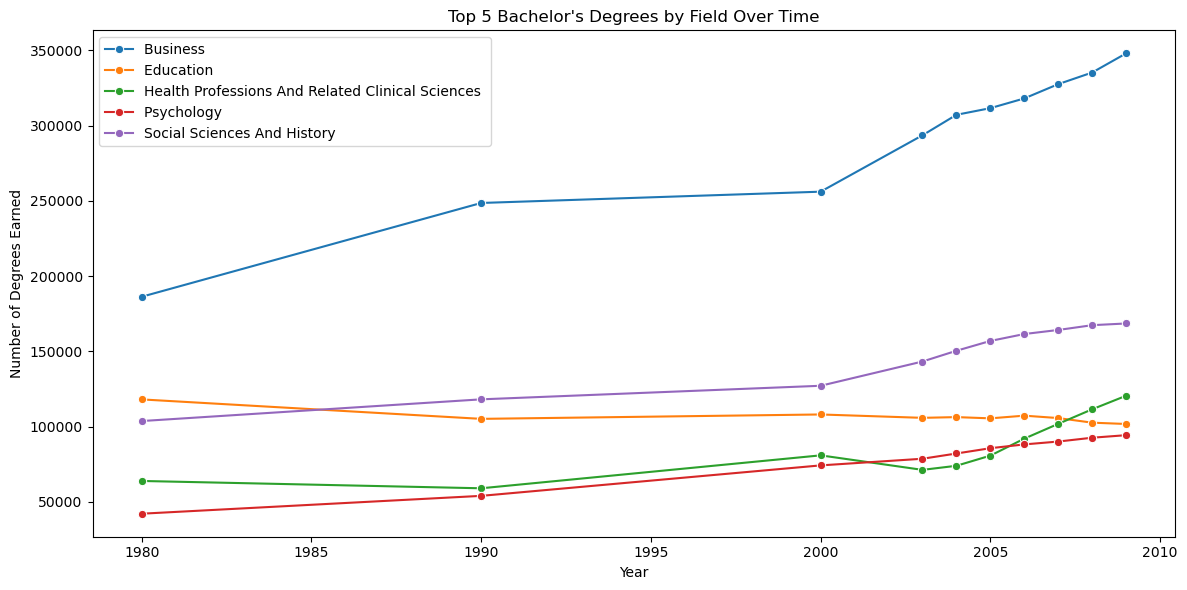

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=df_long, x="Year", y="Degrees", hue="Field of study", marker="o", ax=ax
)
ax.set_title("Top 5 Bachelor's Degrees by Field Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Degrees Earned")
ax.legend(loc="upper left")
plt.tight_layout()

plt.savefig("degree_type_over_time.jpg", dpi=300)
plt.show()